In [1]:
thin2 = 25

Using S = 1557


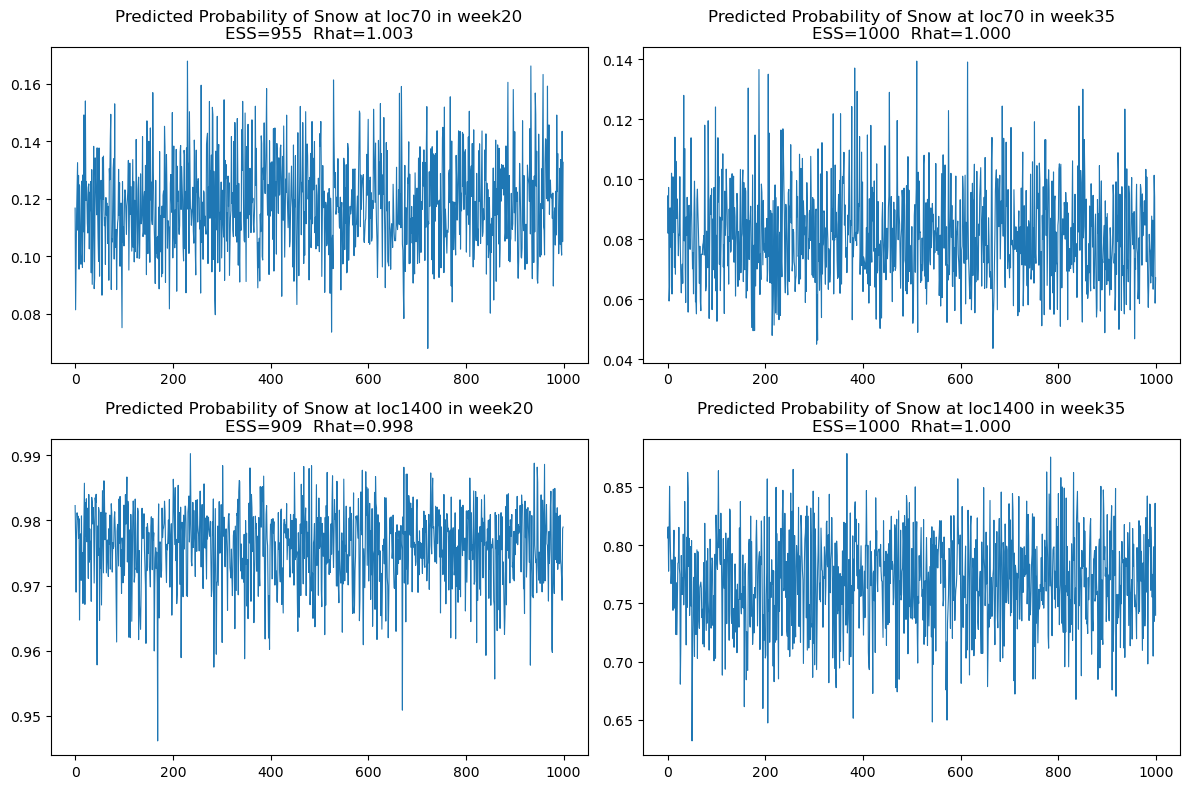

array([[ 87.0054,  33.7931],
       [-90.4077,  46.558 ]])

In [2]:
# ================================================================
# Posterior predictive diagnostics
# traceplot + ESS + Rhat
# EXACTLY same preprocessing as training code
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
import pyreadr
import pickle

from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# ================================================================
# CONFIG
# ================================================================

BASE_DIR = Path(r"D:\77\Research\temp\snow")

n_chains = 5

period = 52

# ================================================================
# ESS
# ================================================================

def autocorr(x, lag):
    n = len(x)
    x = x - x.mean()
    return np.dot(x[:n-lag], x[lag:]) / np.dot(x,x)

def compute_ess(x, max_lag=1000):

    n = len(x)
    rho = []

    for k in range(1,max_lag):

        r = autocorr(x,k)

        if r < 0:
            break

        rho.append(r)

    tau = 1 + 2*np.sum(rho)

    return n / tau

# ================================================================
# RHAT
# ================================================================

def compute_rhat(chains):

    chains = np.array(chains)

    m, n = chains.shape

    chain_means = chains.mean(axis=1)

    B = n * np.var(chain_means, ddof=1)

    W = np.mean(np.var(chains, axis=1, ddof=1))

    var_hat = ((n-1)/n)*W + (1/n)*B

    Rhat = np.sqrt(var_hat / W)

    return Rhat

# ================================================================
# REMOVE NO_NBS
# ================================================================

no_nbs = np.array([
57,170,236,269,343,685,946,947,989,
1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

snow = pyreadr.read_r("snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)

snow = snow.drop(index=no_nbs).reset_index(drop=True)

coords_full = snow.iloc[:,:2].to_numpy()
y_full = snow.iloc[:,2:].to_numpy()

# ================================================================
# TWO LARGEST COMPONENTS
# ================================================================

gdf = gpd.GeoDataFrame(
geometry=gpd.points_from_xy(coords_full[:,0], coords_full[:,1]),
crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

W_full = (squareform(pdist(xy)) <= 0.22).astype(int)
np.fill_diagonal(W_full,0)

W_full = csr_matrix(W_full)

n_comp, labels = connected_components(W_full,directed=False)

sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
np.where(labels==order[0])[0],
np.where(labels==order[1])[0]
]))

coords = coords_full[keep]
y = y_full[keep]

S,TT = y.shape

print("Using S =",S)

# ================================================================
# TIME SCALING
# ================================================================

t_full = np.arange(1,TT+1)
t_scaled_full = (t_full - t_full.mean()) / t_full.std()

# ================================================================
# COVARIATES
# ================================================================

lat_raw = coords[:,1]
lat = (lat_raw - lat_raw.mean()) / lat_raw.std()

elev_raw = pd.read_csv(BASE_DIR/"curr_elev.csv").iloc[:,3].to_numpy()
elev = (elev_raw[keep] - elev_raw[keep].mean()) / elev_raw[keep].std()

snow_temp = pyreadr.read_r(BASE_DIR/"snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)

temp_full = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp_full = temp_full[keep]

temp_scaled = (temp_full - temp_full.mean()) / temp_full.std()

# ================================================================
# TARGET LOCATIONS
# ================================================================

locations = [70,1400]
weeks = [20,35]
year = 20

times = [year*52 + w for w in weeks]

# ================================================================
# LOAD CHAINS
# ================================================================

eta01_list=[]
tau01_list=[]
eta10_list=[]
tau10_list=[]
good_chains = [0,1,2,3,4]   # ignore chain1
n_chains = len(good_chains)

for c in good_chains:

    with open(BASE_DIR/f"bym01_chain{c}+cov.pkl","rb") as f:
        d = pickle.load(f)

    eta01_list.append(d["eta"][:,::thin2])
    tau01_list.append(d["tau"][:,::thin2])

    with open(BASE_DIR/f"bym10_chain{c}+cov.pkl","rb") as f:
        d = pickle.load(f)

    eta10_list.append(d["eta"][:,::thin2])
    tau10_list.append(d["tau"][:,::thin2])

# ================================================================
# DIMENSIONS
# ================================================================

eta_dim = eta01_list[0].shape[0]
S = (eta_dim-3)//8

# ================================================================
# TRACEPLOTS
# ================================================================

fig, axs = plt.subplots(len(locations), len(times), figsize=(12,8))
axs = np.atleast_2d(axs)

for i, s in enumerate(locations):
    for j, t in enumerate(times):

        w = (t-1)%52
        t_scaled = t_scaled_full[t-1]

        cov4 = np.array([
        1,
        np.cos(2*np.pi*t/period),
        np.sin(2*np.pi*t/period),
        t_scaled
        ])

        p_chains=[]

        for c in range(n_chains):

            eta01 = eta01_list[c]
            tau01 = tau01_list[c]
            eta10 = eta10_list[c]
            tau10 = tau10_list[c]

            draws = eta01.shape[1]

            phi01 = np.zeros(draws)
            phi10 = np.zeros(draws)

            for k in range(8):

                beta01 = eta01[k*S+s,:] * tau01[k*52+w,:]
                beta10 = eta10[k*S+s,:] * tau10[k*52+w,:]

                x = cov4[k//2]

                phi01 += beta01*x
                phi10 += beta10*x

            gamma01 = eta01[8*S:8*S+3,:]
            gamma10 = eta10[8*S:8*S+3,:]

            t_lat  = t_scaled * lat[s]
            t_elev = t_scaled * elev[s]
            t_temp = t_scaled * temp_scaled[s,t-1]

            phi01 += gamma01[0]*t_lat + gamma01[1]*t_elev + gamma01[2]*t_temp
            phi10 += gamma10[0]*t_lat + gamma10[1]*t_elev + gamma10[2]*t_temp

            p01 = 1/(1+np.exp(-phi01))
            p10 = 1/(1+np.exp(-phi10))

            y_prev = y[s,t-1]

            if y_prev == 0:
                p = p01
            else:
                p = 1 - p10

            p_chains.append(p)

        # ========================================================
        # Rhat
        # ========================================================

        Rhat = compute_rhat(p_chains)

        # ========================================================
        # POOL CHAINS
        # ========================================================

        p_all = np.concatenate(p_chains)

        ess = compute_ess(p_all)

        ax = axs[i,j]

        ax.plot(p_all, lw=0.8)

        ax.set_title(
        f"Predicted Probability of Snow at loc{s} in week{(t-1)%52+1}\nESS={ess:.0f}  Rhat={Rhat:.3f}"
        )

plt.tight_layout()
plt.show()

coords[[70,1400]]

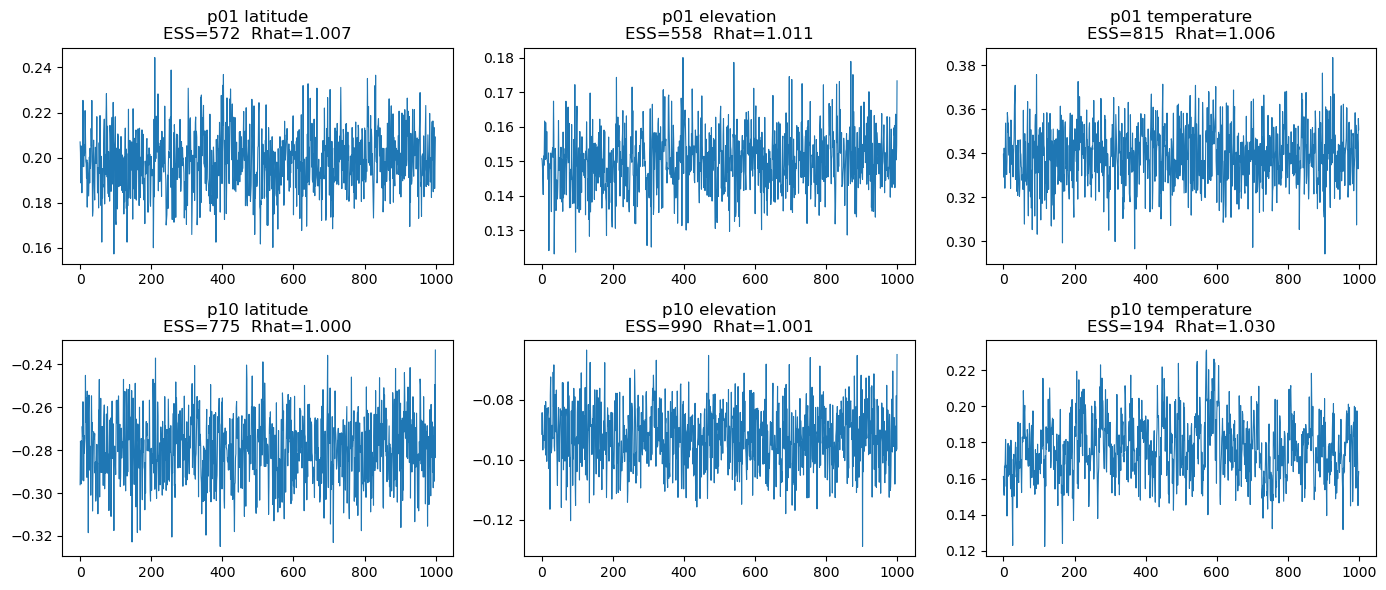

In [3]:
# ================================================================
# GLOBAL COVARIATE TRACEPLOTS
# ================================================================

param_names = ["latitude","elevation","temperature"]

fig, axs = plt.subplots(2,3, figsize=(14,6))

for k in range(3):

    chains = []

    for c in range(n_chains):

        eta = eta01_list[c]

        chains.append(eta[8*S + k, :])

    chains = np.array(chains)

    # Rhat
    Rhat = compute_rhat(chains)

    # pool for ESS
    pooled = np.concatenate(chains)

    ess = compute_ess(pooled)

    ax = axs[0,k]

    ax.plot(pooled, lw=0.8)

    ax.set_title(
        f"p01 {param_names[k]}\nESS={ess:.0f}  Rhat={Rhat:.3f}"
    )


for k in range(3):

    chains = []

    for c in range(n_chains):

        eta = eta10_list[c]

        chains.append(eta[8*S + k, :])

    chains = np.array(chains)

    Rhat = compute_rhat(chains)

    pooled = np.concatenate(chains)

    ess = compute_ess(pooled)

    ax = axs[1,k]

    ax.plot(pooled, lw=0.8)

    ax.set_title(
        f"p10 {param_names[k]}\nESS={ess:.0f}  Rhat={Rhat:.3f}"
    )

plt.tight_layout()
plt.show()

Using S = 1557


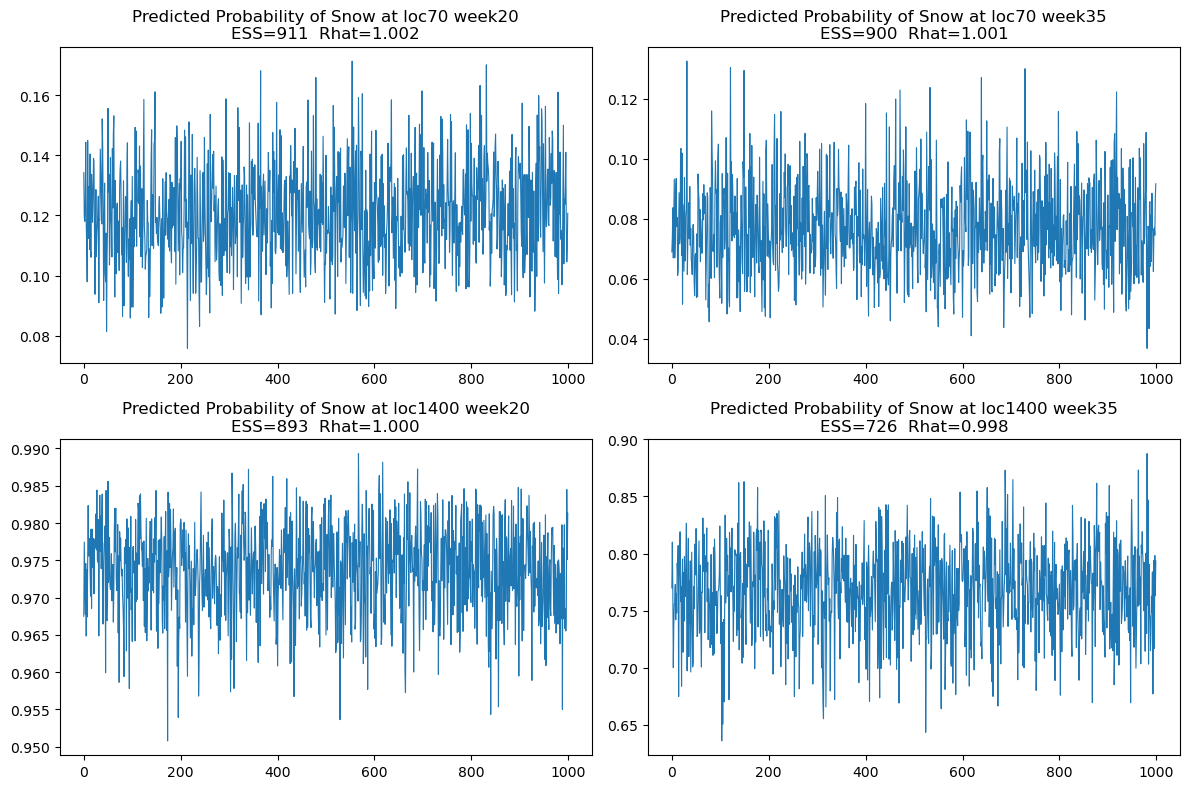

In [4]:
 # ------------- MCMC Plots for BYM without Covs 
 
 # ================================================================
# Posterior predictive diagnostics
# traceplot + ESS + Rhat
# NO COVARIATES VERSION
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
import pyreadr
import pickle

from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components


# ================================================================
# CONFIG
# ================================================================

BASE_DIR = Path(r"D:\77\Research\temp\snow")

good_chains = [0,1,2,3,4]

period = 52


# ================================================================
# ESS
# ================================================================

def autocorr(x, lag):

    n = len(x)
    x = x - x.mean()

    return np.dot(x[:n-lag], x[lag:]) / np.dot(x,x)


def compute_ess(x, max_lag=1000):

    n = len(x)

    rho = []

    for k in range(1,max_lag):

        r = autocorr(x,k)

        if r < 0:
            break

        rho.append(r)

    tau = 1 + 2*np.sum(rho)

    return n / tau


# ================================================================
# RHAT
# ================================================================

def compute_rhat(chains):

    chains = np.array(chains)

    m,n = chains.shape

    chain_means = chains.mean(axis=1)

    B = n*np.var(chain_means,ddof=1)

    W = np.mean(np.var(chains,axis=1,ddof=1))

    var_hat = ((n-1)/n)*W + (1/n)*B

    Rhat = np.sqrt(var_hat/W)

    return Rhat


# ================================================================
# REMOVE NO_NBS
# ================================================================

no_nbs = np.array([
57,170,236,269,343,685,946,947,989,
1037,1084,1090,1109,1118,1127,1176,1203
]) - 1


snow = pyreadr.read_r("snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)

snow = snow.drop(index=no_nbs).reset_index(drop=True)

coords_full = snow.iloc[:,:2].to_numpy()
y_full = snow.iloc[:,2:].to_numpy()


# ================================================================
# TWO LARGEST COMPONENTS
# ================================================================

gdf = gpd.GeoDataFrame(
geometry=gpd.points_from_xy(coords_full[:,0],coords_full[:,1]),
crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x,gdf.geometry.y]).T / 1e6

W_full = (squareform(pdist(xy))<=0.22).astype(int)
np.fill_diagonal(W_full,0)

W_full = csr_matrix(W_full)

n_comp,labels = connected_components(W_full,directed=False)

sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
np.where(labels==order[0])[0],
np.where(labels==order[1])[0]
]))

coords = coords_full[keep]
y = y_full[keep]

S,TT = y.shape

print("Using S =",S)


# ================================================================
# TIME SCALING
# ================================================================

t_full = np.arange(1,TT+1)
t_scaled_full = (t_full - t_full.mean()) / t_full.std()


# ================================================================
# TARGET LOCATIONS
# ================================================================

locations = [70,1400]
weeks = [20,35]
year = 20

times = [year*52 + w for w in weeks]


# ================================================================
# LOAD CHAINS
# ================================================================

eta01_list=[]
tau01_list=[]

eta10_list=[]
tau10_list=[]


for c in good_chains:

    with open(BASE_DIR/f"bym01_chain{c}.pkl","rb") as f:
        d = pickle.load(f)

    eta01_list.append(d["eta"][:,::thin2])
    tau01_list.append(d["tau"][:,::thin2])

    with open(BASE_DIR/f"bym10_chain{c}.pkl","rb") as f:
        d = pickle.load(f)

    eta10_list.append(d["eta"][:,::thin2])
    tau10_list.append(d["tau"][:,::thin2])


n_chains = len(good_chains)


# ================================================================
# DIMENSIONS
# ================================================================

eta_dim = eta01_list[0].shape[0]

S = eta_dim // 8


# ================================================================
# TRACEPLOTS
# ================================================================

fig,axs = plt.subplots(len(locations),len(times),figsize=(12,8))
axs = np.atleast_2d(axs)


for i,s in enumerate(locations):

    for j,t in enumerate(times):

        w = (t-1)%52
        t_scaled = t_scaled_full[t-1]

        cov4 = np.array([
        1,
        np.cos(2*np.pi*t/period),
        np.sin(2*np.pi*t/period),
        t_scaled
        ])

        p_chains=[]

        for c in range(n_chains):

            eta01 = eta01_list[c]
            tau01 = tau01_list[c]

            eta10 = eta10_list[c]
            tau10 = tau10_list[c]

            draws = eta01.shape[1]

            phi01 = np.zeros(draws)
            phi10 = np.zeros(draws)

            for k in range(8):

                beta01 = eta01[k*S+s,:] * tau01[k*52+w,:]
                beta10 = eta10[k*S+s,:] * tau10[k*52+w,:]

                x = cov4[k//2]

                phi01 += beta01*x
                phi10 += beta10*x


            p01 = 1/(1+np.exp(-phi01))
            p10 = 1/(1+np.exp(-phi10))

            y_prev = y[s,t-1]

            if y_prev == 0:
                p = p01
            else:
                p = 1 - p10

            p_chains.append(p)


        # ========================================================
        # RHAT
        # ========================================================

        Rhat = compute_rhat(p_chains)


        # ========================================================
        # POOL CHAINS
        # ========================================================

        p_all = np.concatenate(p_chains)

        ess = compute_ess(p_all)

        ax = axs[i,j]

        ax.plot(p_all,lw=0.8)

        ax.set_title(
        f"Predicted Probability of Snow at loc{s} week{(t-1)%52+1}\nESS={ess:.0f}  Rhat={Rhat:.3f}"
        )


plt.tight_layout()
plt.show()